In [1]:
import sys
from pathlib import Path

parent_dir = Path().resolve().parent
sys.path.insert(0, str(parent_dir))
from map2grid import *

In [2]:
gdf_power = load_osm_data('VNM')

../../../data/osm/vietnam-latest.osm.pbf


extract points: 100%|██████████| 88015/88015 [00:17<00:00, 4985.10it/s]
Warning 1: Non closed ring detected. To avoid accepting it, set the OGR_GEOMETRY_ACCEPT_UNCLOSED_RING configuration option to NO
Warning 1: Non closed ring detected. To avoid accepting it, set the OGR_GEOMETRY_ACCEPT_UNCLOSED_RING configuration option to NO
extract multipolygons:   0%|          | 1/509 [00:18<2:39:07, 18.80s/it]Warning 1: Non closed ring detected. To avoid accepting it, set the OGR_GEOMETRY_ACCEPT_UNCLOSED_RING configuration option to NO
Warning 1: Non closed ring detected. To avoid accepting it, set the OGR_GEOMETRY_ACCEPT_UNCLOSED_RING configuration option to NO
extract lines: 100%|██████████| 9274/9274 [00:16<00:00, 567.47it/s] 


Initial number of results: 97798
After removing contained points: 96704
After removing contained polygons: 96697


/scistor/ivm/mye500/miniconda3/envs/py310/lib/python3.10/site-packages/geopandas/geoseries.py:645: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  result = super().apply(func, convert_dtype=convert_dtype, args=args, **kwargs)


After removing exact duplicates: 96697


In [3]:
output_path="../data/osm"
gens = import_osm_infras(gdf_power, 'power', ['plant', 'generator'], output_path)
lines = import_osm_infras(gdf_power, 'power', ['line', 'minor_line', 'cable'], output_path)
subs = import_osm_infras(gdf_power, 'power', ['substation'], output_path)
trafos = import_osm_infras(gdf_power, 'power', ['transformer'], output_path)

Number of ['plant', 'generator']: 1892
Column 'osm_id' has None values


Number of unmatched geometries: 253


/tmp/ipykernel_889966/1916647988.py:2: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  gens = import_osm_infras(gdf_power, 'power', ['plant', 'generator'], output_path)


Number of ['line', 'minor_line', 'cable']: 7979
Column 'osm_id' doesn't have None values
Number of ['substation']: 1144
Column 'osm_id' has None values
Number of unmatched geometries: 0


/tmp/ipykernel_889966/1916647988.py:4: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  subs = import_osm_infras(gdf_power, 'power', ['substation'], output_path)


Number of ['transformer']: 566
Column 'osm_id' doesn't have None values


In [4]:
gens.crs

<Projected CRS: EPSG:32648>
Name: WGS 84 / UTM zone 48N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 102°E and 108°E, northern hemisphere between equator and 84°N, onshore and offshore. Cambodia. China. Indonesia. Laos. Malaysia - West Malaysia. Mongolia. Russian Federation. Singapore. Thailand. Vietnam.
- bounds: (102.0, 0.0, 108.0, 84.0)
Coordinate Operation:
- name: UTM zone 48N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [5]:
# if subs['osm_id'].isnull().any():
#     print("osm_id 列包含空值")
# else:
#     print("osm_id 列没有空值")

In [6]:
nodes_gdf = extract_unique_endpoints(lines)

In [7]:
updated_gdf = add_endnodes_to_lines(lines, nodes_gdf)  # 为原始数据添加node1和node2列

In [8]:
subs_update = transform_osm_subs(subs)

In [9]:
data_ways_update_osm_id, nodes_in_osm_subs = add_osm_ids_to_data(updated_gdf, subs_update)

In [10]:
# if 'geom_centroid' in subs_update.columns:
#     # 如果需要保留 'alt_geometry'，可以将其转换为 WKT 格式
#     subs_update['geom_centroid_wkt'] = subs_update['geom_centroid'].apply(lambda geom: geom.wkt if geom else None)
#     subs_update = subs_update.drop(columns=['geom_centroid'])  # 删除原始几何列

In [11]:
data_ways_all_voltage = count_voltage_levels(data_ways_update_osm_id)

Start counting voltage levels...
Voltage levels count:
Voltage level 110 kV: 2143
Voltage level 220 kV: 979
Voltage level 500 kV: 2986
Voltage level 230 kV: 1
Voltage level 115 kV: 4
Count of rows with None voltage: 1914


In [12]:
buffer_distance = 500

# Define boolean options
bool_options = {
    'beeline_visu_threshold_diff_percent': 5,  # 视觉化时的阈值（百分比）
    'beeline_visu_threshold_diff_absolut': 0.5,  # 视觉化时的阈值（绝对值，公里）

    # 推荐的可视化选项
    'plot_ways_original': True,  # 可视化所有选定的线路（原始数据集）
    'plot_ways_grouping': True,  # 在分组时可视化所有选定的线路
    'plot_ways_final': True,  # 在地图上可视化所有选定的线路（最终数据集）

    # 可选的可视化选项（用于调试和深入研究）
    'histogram_length_busbars': True,  # 可视化busbars的长度
    'histogram_distances_between_endpoints': True,
    'histogram_stacked_endnodes': True,  # 可视化堆叠的端点数量
    'plot_stacked_endnodes': True,  # 在地图上可视化所有堆叠的端点
}

Start deleting ways with type "busbar" or "bay"...
   ATTENTION! Way Element ID 1192068132 has type "busbar" or "bay", but is too long.
               Length: 0.26 km of max. 0.2 km
               This way won't be added to the "busbar" exception list.
   ATTENTION! Way Element ID 1192068133 has type "busbar" or "bay", but is too long.
               Length: 0.24 km of max. 0.2 km
               This way won't be added to the "busbar" exception list.
   ATTENTION! Way Element ID 1192103425 has type "busbar" or "bay", but is too long.
               Length: 0.20 km of max. 0.2 km
               This way won't be added to the "busbar" exception list.
   ATTENTION! Way Element ID 1192103426 has type "busbar" or "bay", but is too long.
               Length: 0.20 km of max. 0.2 km
               This way won't be added to the "busbar" exception list.
   ATTENTION! Way Element ID 1192103430 has type "busbar" or "bay", but is too long.
               Length: 0.20 km of max. 0.2 km
          

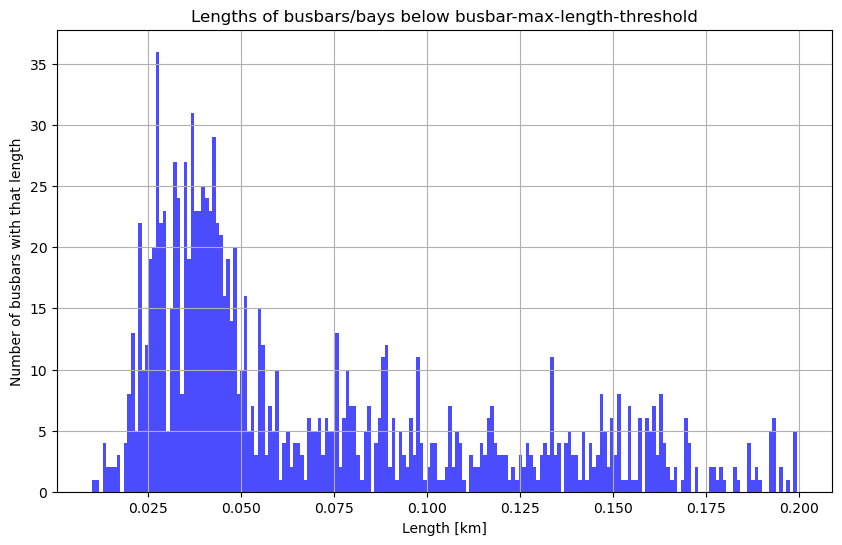

   ... there are 1354 busbars/bays in total
   ... 1217 busbars have been deleted
   ... finished! (0.623 seconds) 



In [13]:
data_ways_busbar, data_busbars = delete_busbars(data_ways_all_voltage, bool_options)

In [14]:
data_ways_dc, dc_candidates = count_possible_dc(data_ways_busbar)

Start detecting lines which could be DC lines...
   ... 658 ways could potentially be a DC line.
   ... Please refer to dc_candidates for further checks.
   ... finished! (0.363 seconds) 



In [15]:
data_ways_cables = count_cables(data_ways_dc)

Start counting cables per way...

    cables_per_way  number_of_ways
0               3            3007
1               6            1863
2               1             658
3              12             123
4               9              40
5              18               2
6               4               2
7               8               1
8              20               1
9              11               1
   ... 1112 ways with unknown number of cables.
   ... ways with 6 cables will be doubled, ways with 9 cables tripled and ways with 12 cables quadrupled.
   ... finished!


   ... start visualizing all distances in a histogram ...


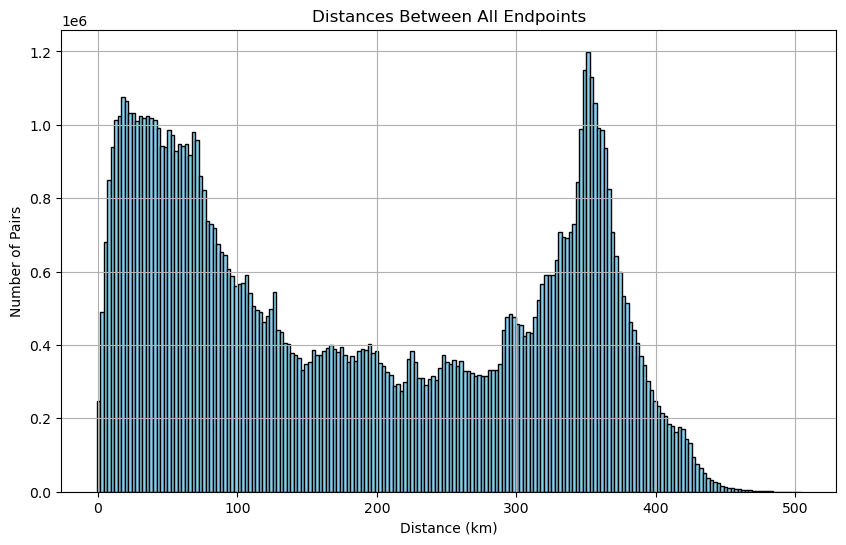

In [16]:
M = calc_distances_between_endpoints(data_ways_cables, bool_options)

Start finding all stacked endnodes...
... 9678 endnodes are stacked!
... finished! (0.693 seconds)

Reprojecting CRS from EPSG:32648 to EPSG:32648.


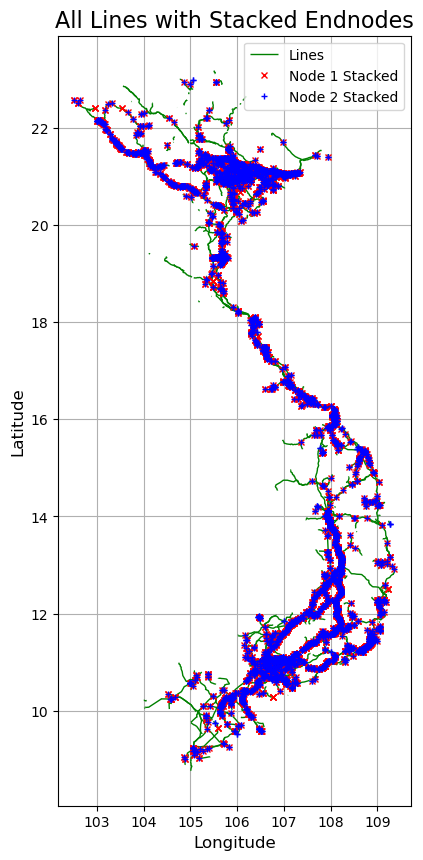

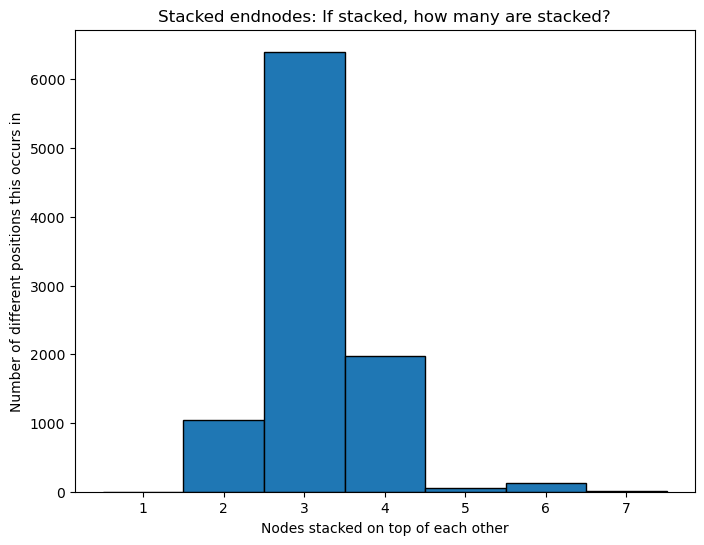

In [17]:
data_ways_stacked, nodes_stacked_pairs = calc_stacked_endnodes(data_ways_cables, M, bool_options)

In [18]:
nodes_stacked_grouped = group_nodes(nodes_stacked_pairs)

Start grouping all pairs from "pairs_input" (may take a few seconds)...
   ... 9678 nodes will be grouped together in 3192 groups,
       with an average of 3.03 nodes per group.
   ... finished! (2.138 seconds)



In [19]:
data_ways_group_stacked_nodes = group_stacked_endnodes(data_ways_cables, nodes_gdf, nodes_stacked_grouped)

Completed updating coordinates for stacked groups.


In [20]:
data_ways_final_coords = add_final_coordinates(data_ways_group_stacked_nodes)

Start adding final coordinates...
... finished!


In [21]:
data_ways_delete, data_singular_ways = delete_singular_ways(data_ways_final_coords, 'ID_node1_final', 'ID_node2_final')

Start deleting ways which have the same endpoints after grouping...
   ... 1485 ways were deleted!
   ... finished! (0.006 seconds)


In [95]:
def plot_ways_original(data, data_busbars, bool_options, data_singular_ways, voltage_levels_selected=[110000, 115000, 220000, 230000, 500000]):
    """
    This function plots the original dataset as it was with selected voltage levels.
    Two plots will be generated if the flag in bool_options is set:
    A plot with a lon/lat coordinate system and a plot with a more intuitive x/y plot in km.
    """
    data.set_crs(epsg=32648, inplace=True)
    data = data.to_crs(epsg=4326)
    data_busbars = gpd.GeoDataFrame(data_busbars, geometry='geometry', crs='EPSG:32648').to_crs(epsg=4326)
    data_singular_ways = gpd.GeoDataFrame(data_singular_ways, geometry='geometry', crs='EPSG:32648').to_crs(epsg=4326)

    print(data.crs, data_busbars.crs, data_singular_ways.crs)

    if bool_options.get('plot_ways_original', False):
        print('Start plotting original ways... (takes a few seconds)')
        
        # Create custom 12-color qualitative colormap for better distinctness
        colormap = np.array([
            [51, 160, 44], [31, 120, 180], [177, 89, 40], [106, 61, 154],
            [255, 127, 0], [178, 223, 138], [227, 26, 28], [255, 255, 153],
            [166, 206, 227], [202, 178, 214], [251, 154, 153], [253, 191, 111]
        ]) / 255
        
        # Create figure for deg Plot
        fig, ax = plt.subplots()
        ax.grid(True)
        ax.set_title('Original Ways, Only Selected Voltages')
        ax.set_xlabel('Longitude [°]')
        ax.set_ylabel('Latitude [°]')
        
        # Add data_busbars with legend
        label_set_busbars = False
        for geom in data_busbars['geometry']:
            coords = np.array(geom.coords)
            lon = coords[:, 0]
            lat = coords[:, 1]
            if not label_set_busbars:
                ax.plot(lon, lat, 'cx-', color="#dec5e3", linewidth=1, label="Busbars")
                label_set_busbars = True
            else:
                ax.plot(lon, lat, 'cx-', color="#dec5e3", linewidth=1)

        # Add data_singular_ways with legend
        label_set_singular_ways = False
        for geom in data_singular_ways['geometry']:
            coords = np.array(geom.coords)
            lon = coords[:, 0]
            lat = coords[:, 1]
            if not label_set_singular_ways:
                ax.plot(lon, lat, 'kx-', color="#73d2de", linewidth=1, label="Deleted Ways")
                label_set_singular_ways = True
            else:
                ax.plot(lon, lat, 'kx-', color="#73d2de", linewidth=1)

        # Plot voltage levels with legend
        voltage_labels_added = set()  # Keep track of added labels
        for i_vlevel in range(len(voltage_levels_selected) - 1, -1, -1):
            i_colormap = i_vlevel - (i_vlevel // 12) * 12
            current_color = colormap[i_colormap]
            current_voltage = int(voltage_levels_selected[i_vlevel])
            label = f"{current_voltage // 1000} kV"  # Voltage level label
            
            # Get all ways with the current voltage level
            current_ways = data[data['voltage'] == current_voltage]
            
            # Plot the actual LineString data
            for geom in current_ways['geometry']:
                coords = np.array(geom.coords)
                lon = coords[:, 0]
                lat = coords[:, 1]
                if label not in voltage_labels_added:
                    ax.plot(lon, lat, '-o', color=current_color, markersize=1, label=label)
                    voltage_labels_added.add(label)
                else:
                    ax.plot(lon, lat, '-o', color=current_color, markersize=1)

        # Set plot limits
        xlim = (107.631, 107.640)
        ylim = (11.964, 11.9722)
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        
        # Add legend
        ax.legend(loc='upper left', frameon=False)
        
        # Show the plot
        plt.show()


EPSG:4326 EPSG:4326 EPSG:4326
Start plotting original ways... (takes a few seconds)


/tmp/ipykernel_889966/1670770392.py:38: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "cx-" (-> color='c'). The keyword argument will take precedence.
  ax.plot(lon, lat, 'cx-', color="#dec5e3", linewidth=1, label="Busbars")
/tmp/ipykernel_889966/1670770392.py:41: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "cx-" (-> color='c'). The keyword argument will take precedence.
  ax.plot(lon, lat, 'cx-', color="#dec5e3", linewidth=1)
/tmp/ipykernel_889966/1670770392.py:50: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "kx-" (-> color='k'). The keyword argument will take precedence.
  ax.plot(lon, lat, 'kx-', color="#73d2de", linewidth=1, label="Deleted Ways")
/tmp/ipykernel_889966/1670770392.py:53: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "kx-" (-> color='k'). The keyword argument will take precedence

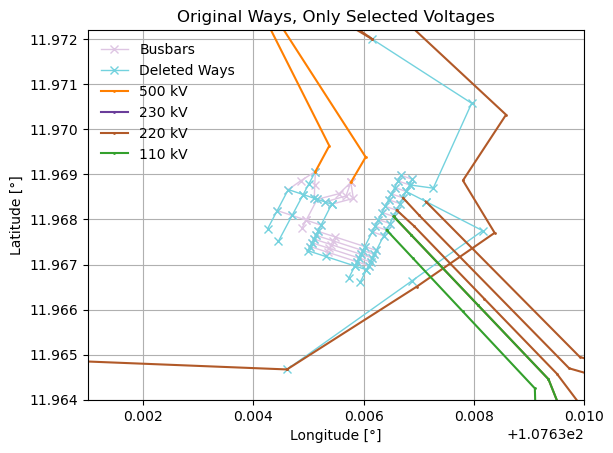

In [96]:
plot_ways_original(data_ways_delete, data_busbars, bool_options, data_singular_ways)

In [84]:
data_ways_clone = add_lineID_clone_ways(data_ways_delete)

Start adding "LineID" and cloning ways...
   ... 1586 ways doubled, 38 tripled, 112 quadrupled.
   ... finished! (4.540 seconds) 



In [87]:
table_lines = fill_line_voltage(data_ways_clone)

In [88]:
# remaining_empty_voltage = table_lines[table_lines['Voltage'].isna()]
# remaining_empty_voltage

In [89]:
table_lines_update = table_lines.dropna(subset=['voltage'])

In [90]:
table_lines_update

,osm_id,power,voltage,utility,name,frequency,plant_output_electricity,plant_source,plant_method,generator_output_electricity,...,lat1_grouped,lon2_grouped,lat2_grouped,ID_node1_final,lon1_final,lat1_final,ID_node2_final,lon2_final,lat2_final,LineID
0,153608701,line,110000,None,None,50,None,None,None,None,...,NaN,609979.512105,2.317122e+06,1.536087e+08,610714.852695,2.315181e+06,1.000000e+00,609979.512105,2.317122e+06,LINEVN0001a
1,153608701,line,110000,None,None,50,None,None,None,None,...,NaN,609979.512105,2.317122e+06,1.536087e+08,610714.852695,2.315181e+06,1.000000e+00,609979.512105,2.317122e+06,LINEVN0001b
2,176708144,line,110000,None,None,50,None,None,None,None,...,NaN,NaN,NaN,2.000000e+00,672622.408581,1.278800e+06,1.197858e+09,651889.179899,1.285444e+06,LINEVN0002
3,241194661,line,220000,None,None,50,None,None,None,None,...,2.315888e+06,684741.069151,2.304331e+06,4.000000e+00,682154.017051,2.315888e+06,2.410654e+08,684741.069151,2.304331e+06,LINEVN0003a
4,241194661,line,220000,None,None,50,None,None,None,None,...,2.315888e+06,684741.069151,2.304331e+06,4.000000e+00,682154.017051,2.315888e+06,2.410654e+08,684741.069151,2.304331e+06,LINEVN0003b
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7316,1338330546,line,110000,None,None,None,None,None,None,None,...,2.317009e+06,NaN,NaN,8.962000e+03,581691.576202,2.317009e+06,8.963000e+03,583505.747488,2.315733e+06,LINEVN5321a
7317,1338330546,line,110000,None,None,None,None,None,None,None,...,2.317009e+06,NaN,NaN,8.962000e+03,581691.576202,2.317009e+06,8.963000e+03,583505.747488,2.315733e+06,LINEVN5321b
7318,1338330547,line,110000,None,None,None,None,None,None,None,...,NaN,581691.576202,2.317009e+06,8.964000e+03,580538.606852,2.317070e+06,8.962000e+03,581691.576202,2.317009e+06,LINEVN5322a
7319,1338330547,line,110000,None,None,None,None,None,None,None,...,NaN,581691.576202,2.317009e+06,8.964000e+03,580538.606852,2.317070e+06,8.962000e+03,581691.576202,2.317009e+06,LINEVN5322b


In [91]:
# if table_lines_update['Voltage'].isna().any():
#     print("There are still missing values in the Voltage column.")
# else:
#     print("All missing values in the Voltage column have been filled.")

In [92]:
output_dir = '../outputs'
export_data(table_lines_update, output_dir)

Start exporting data to Excel files... (may take a few seconds)
INFO: Exported lines to ../outputs/tbl_Lines_VN_500m.xlsx
INFO: Exported Nodes to ../outputs/../outputs/tbl_Nodes_VN_500m.xlsx
... finished!
